In [1]:
# K-Means Clustering for Customer Segmentation
# Author: MANIKANDAPRABHU.S
# Objective: Segment mall customers into groups based on Annual Income and Spending Score using K-Means Clustering.


In [2]:
## 1. Import Libraries
import pandas as pd
import os
os.environ["OMP_NUM_THREADS"] = "1"

print("OMP_NUM_THREADS =", os.environ["OMP_NUM_THREADS"])

OMP_NUM_THREADS = 1


In [3]:
## 2. Loading the Dataset
dataset=pd.read_csv("Mall_Customers.csv")

In [4]:
## 3. Exploring the Dataset
dataset

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [5]:
## 4. Preparing Features
x=dataset.iloc[:,[3,4]].values

Text(0, 0.5, 'WCSS')

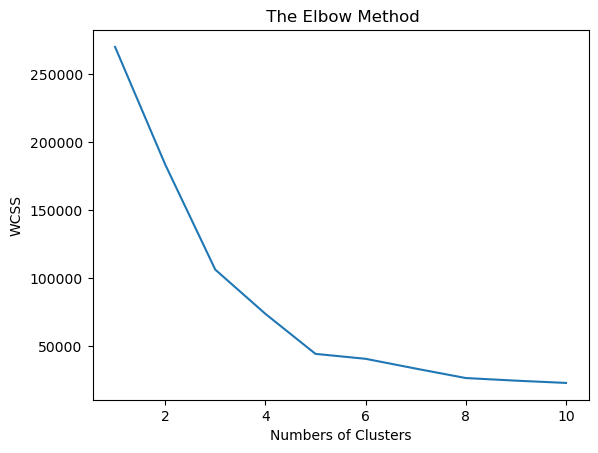

In [6]:
## 5. Finding the Optimal Number of Clusters
import matplotlib .pyplot as plt
from sklearn.cluster import KMeans
listi=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i,init='k-means++',random_state=42)
    kmeans.fit(x)
    listi.append(kmeans.inertia_)
plt.plot(range(1,11),listi)
plt.title(' The Elbow Method')
plt.xlabel('Numbers of Clusters')
plt.ylabel('WCSS')

In [7]:
## 6. Training the K-Means Clustering Model
from sklearn.cluster import KMeans
kmeans=KMeans(n_clusters=5,init='k-means++',random_state=42)
y_kmeans=kmeans.fit_predict(x)

In [8]:
## 7. Cluster Labels
y_kmeans

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [9]:
## 8. Creating the Clustered Dataset
supervised=pd.DataFrame(dataset)

In [10]:
## 9. Adding Cluster Groups
supervised['Cluster_group']=y_kmeans

In [11]:
## 10. Displaying Clustered Data
supervised

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster_group
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4
...,...,...,...,...,...,...
195,196,Female,35,120,79,1
196,197,Female,45,126,28,3
197,198,Male,32,126,74,1
198,199,Male,32,137,18,3


In [12]:
## 11. Saving Clustered Data
supervised.to_csv("cluster.csv",index=False)

In [13]:
## 12. Finding Cluster Centroids
centroids=kmeans.cluster_centers_

In [14]:
## 13. Displaying Cluster Centroids
centroids

array([[55.2962963 , 49.51851852],
       [86.53846154, 82.12820513],
       [25.72727273, 79.36363636],
       [88.2       , 17.11428571],
       [26.30434783, 20.91304348]])

In [15]:
## 14. Checking Cluster Labels
y_kmeans

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [16]:
## 15. Installing Visualization Library
!pip install seaborn

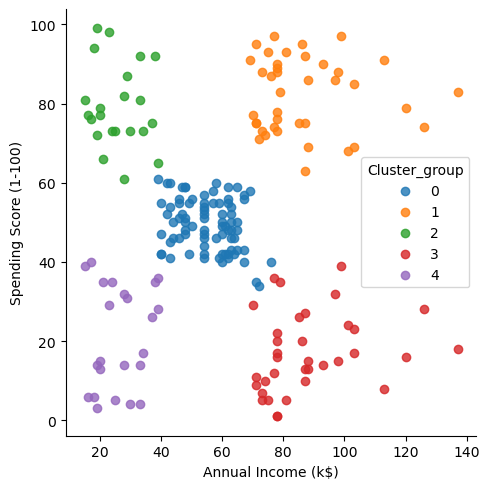

In [17]:
## 16. Initial Cluster Visualization
import seaborn as sns
facet=sns.lmplot(data=supervised,x=supervised.columns[3],y=supervised.columns[4],hue=supervised.columns[5],fit_reg=False,legend=True,facet_kws={"legend_out": False})

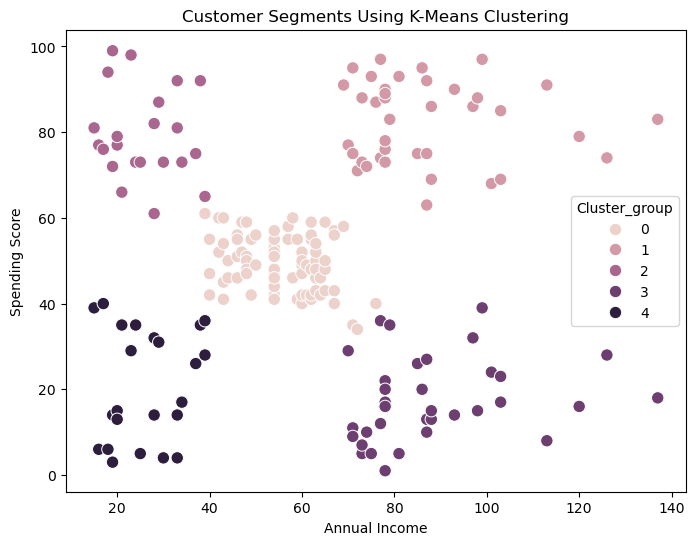

In [18]:
## 17. Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=supervised,
    x=supervised.columns[3],
    y=supervised.columns[4],
    hue="Cluster_group",
    s=80
)
plt.title("Customer Segments Using K-Means Clustering")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()


In [19]:
## 18. Saving the Trained Model
import pickle

filename = "KMeans_Clustering_Model.sav"
with open(filename, "wb") as file:
    pickle.dump(kmeans, file)
print("K-Means model saved successfully.")


K-Means model saved successfully.


In [20]:
## 19. Conclusion
# The K-Means clustering model groups customers into five clusters
# using Annual Income and Spending Score. The clustered dataset and
# trained model are saved for later use.
